# ==========================================================
# Rice Image Classification using Deep Learning
# Author: Muhammad Aulia Anhar
# ==========================================================



# 1. INTRODUCTION

Notebook ini disusun sebagai bagian dari penelitian klasifikasi beras berbasis citra
mendukung penulisan artikel ilmiah SINTA 3.
menggunakan pendekatan deep learning. Notebook ini bersifat journal-ready dan


Tujuan eksperimen:
1. Membangun baseline CNN untuk klasifikasi beras
2. Membandingkan performa CNN, ResNet, dan Vision Transformer
3. Mengevaluasi pengaruh data augmentation

A. Penanganan Data Imbalance (Penting!)
Data Anda sangat tidak seimbang (Kelas 0_NOR memiliki 18.000 gambar, sementara kelas lain hanya ~1.300).

Saran: Jangan hanya menggunakan Random Augmentation. Gunakan teknik Oversampling pada kelas minoritas atau Weighted Loss Function (misalnya Weighted Cross Entropy) dalam training loop. Dokumentasikan perbandingannya.

# 2. IMPORT LIBRARIES & DEVICE SETUP

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time
import copy  # <--- Ini yang menyebabkan error tadi
import os
from sklearn.metrics import classification_report, confusion_matrix

# Setup Device (GPU jika tersedia)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan perangkat: {device}")

Menggunakan perangkat: cuda


# 3. DESKRIPSI DATA
mendefinisikan di mana data berada dan melakukan inspeksi awal untuk melihat berapa banyak kelas yang

In [2]:
# Tentukan path sesuai struktur folder Anda
train_dir = "C:/Users/Anhar/Documents/#Semester 8/Project/Dataset/rice/train"
test_dir = "C:/Users/Anhar/Documents/#Semester 8/Project/Dataset/rice/test"


# Fungsi untuk mendeskripsikan isi dataset
def describe_dataset(directory):
    classes = os.listdir(directory)
    data_info = []
    total_images = 0

    for class_name in classes:
        path = os.path.join(directory, class_name)
        if os.path.isdir(path):
            n_images = len(os.listdir(path))
            data_info.append({"Kelas": class_name, "Jumlah Gambar": n_images})
            total_images += n_images

    df = pd.DataFrame(data_info)
    return df, total_images


# Eksekusi deskripsi data
train_stats, total_train = describe_dataset(train_dir)
test_stats, total_test = describe_dataset(test_dir)

print(f"Total gambar Training: {total_train}")
print("Detail per Kelas (Training):")
print(train_stats)

print(f"\nTotal gambar Testing: {total_test}")
print("Detail per Kelas (Testing):")
print(test_stats)

Total gambar Training: 27862
Detail per Kelas (Training):
   Kelas  Jumlah Gambar
0  0_NOR          18000
1  1_F&S           1336
2   2_SD           1350
3   3_MY           1350
4   4_AP           1350
5   5_BN           1341
6   6_UN           1335
7   7_IM           1800

Total gambar Testing: 3100
Detail per Kelas (Testing):
   Kelas  Jumlah Gambar
0  0_NOR           2000
1  1_F&S            150
2   2_SD            150
3   3_MY            150
4   4_AP            150
5   5_BN            150
6   6_UN            150
7   7_IM            200


# 4. explorasi data analysis (EDA)

visualisasikan ketimpangan data (imbalance) sebagai alasan menggunakan Skenario Optimasi nanti

### A. Visualisasi Distribusi Kelas

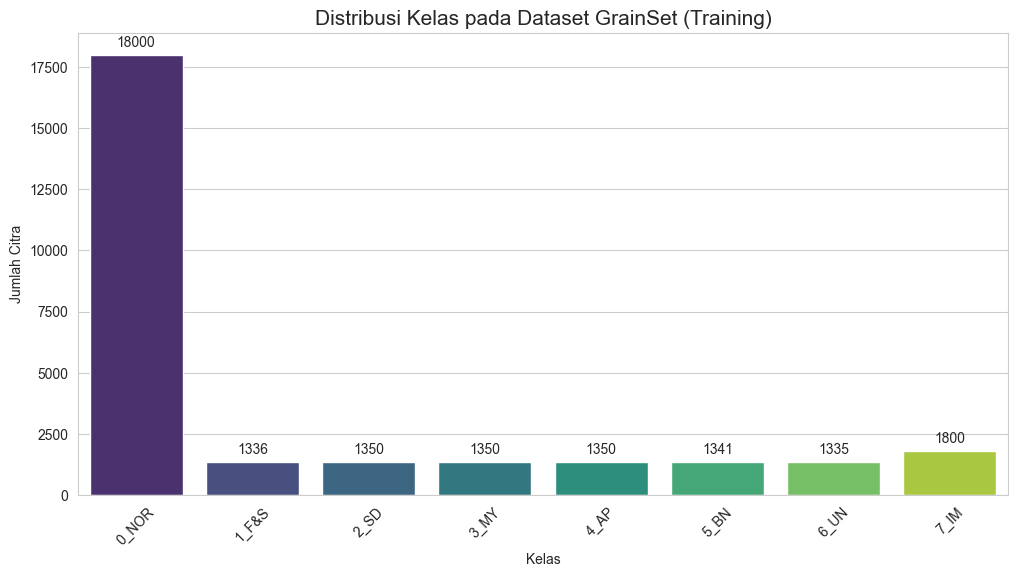

In [3]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(
    x="Kelas",
    y="Jumlah Gambar",
    data=train_stats,
    hue="Kelas",
    legend=False,
    palette="viridis",
)

plt.title("Distribusi Kelas pada Dataset GrainSet (Training)", fontsize=15)
plt.xticks(rotation=45)
plt.ylabel("Jumlah Citra")

import matplotlib.patches as mpatches

# Tambahkan label angka di atas bar
for p in ax.patches:
    if isinstance(p, mpatches.Rectangle):
        x = p.get_x() + p.get_width() / 2.0
        y = p.get_height()
        ax.annotate(
            format(y, ".0f"),
            (x, y),
            ha="center",
            va="center",
            xytext=(0, 9),
            textcoords="offset points",
        )
plt.show()

### Analisis Ketimpangan Data (Imbalance)
Data Anda sangat tidak seimbang:

Kelas Mayoritas: 0_NOR (18.000 gambar) — ini adalah 64% dari total data training.

Kelas Minoritas: Kelas 1 sampai 6 (hanya sekitar 1.300-an gambar per kelas).

Dampak: Ada perbedaan jumlah hampir 13 kali lipat antara kelas normal dan kelas cacat lainnya.

**Dataset yang digunakan terdiri dari citra beras yang dibagi menjadi 8 kelas berbeda. Berdasarkan inspeksi data dalam notebook:**

Total Data Training: 27.862 gambar.

Total Data Testing: 3.100 gambar.

Kelas Beras: Mencakup kelas 0_NOR, 1_F&S, 2_SD, 3_MY, 4_AP, 5_BN, 6_UN, dan 7_IM.

Terdapat indikasi ketimpangan data (data imbalance), di mana kelas 0_NOR memiliki jumlah gambar yang jauh lebih banyak (18.000 pada training) dibandingkan kelas lainnya.

### B. Visualisasi Sampel Gambar (Cek Kualitas)

contoh gambar dari setiap kategori

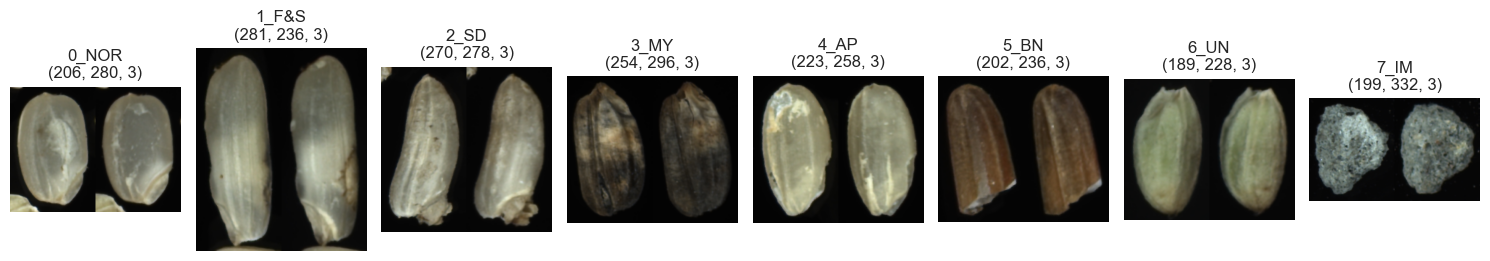

In [4]:
def show_samples(directory, num_samples=1):
    classes = os.listdir(directory)
    plt.figure(figsize=(15, 5))

    for i, class_name in enumerate(classes):
        class_path = os.path.join(directory, class_name)
        img_name = os.listdir(class_path)[0]
        img_path = os.path.join(class_path, img_name)

        img = plt.imread(img_path)
        plt.subplot(1, len(classes), i + 1)
        plt.imshow(img)
        plt.title(f"{class_name}\n{img.shape}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_samples(train_dir)

In [5]:
# Wadah untuk menyimpan hasil eksperimen
results_matrix = {
    "Skenario 1": {"MobileNetV3": None, "ResNet50": None, "ViT-Small": None},
    "Skenario 2": {"MobileNetV3": None, "ResNet50": None, "ViT-Small": None},
    "Skenario 3": {"MobileNetV3": None, "ResNet50": None, "ViT-Small": None},
}


def save_to_matrix(scenario, model_name, history, report, cm, total_time):
    if scenario not in results_matrix:
        raise ValueError(f"Skenario '{scenario}' tidak ada. Pilihan: {list(results_matrix.keys())}")

    if model_name not in results_matrix[scenario]:
        raise ValueError(
            f"Model '{model_name}' tidak ada di {scenario}. "
            f"Pilihan model: {list(results_matrix[scenario].keys())}"
        )

    results_matrix[scenario][model_name] = {
        "history": history,
        "report": report,
        "cm": cm,
        "time": total_time,
    }

    print(f"✅ Data {model_name} pada {scenario} tersimpan.")

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import numpy as np
import torch


def evaluate_and_save(scenario, model_name, model, test_loader, history, total_time):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    report = classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.classes,
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)

    results_matrix[scenario][model_name] = {
        "history": history,
        "report": report,
        "cm": cm,
        "time": total_time,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Time": total_time,
        "Full Report": report,
        "Confusion Matrix": cm,
    }

    print(f"✅ Hasil {model_name} pada {scenario} berhasil disimpan.")
    print(f"Accuracy   : {acc * 100:.2f}%")
    print(f"Macro F1   : {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")

# 5. Modeling dengan Skenario Skenario C (focal loss)


### A. MKelas (focal loss)


In [7]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np

# 1. Transformasi Data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 2. Load Dataset
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

# 3. DataLoader tanpa WeightedRandomSampler
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Dataset berhasil dimuat tanpa WeightedRandomSampler.")
print(f"Jumlah data training: {len(train_dataset)}")
print(f"Jumlah data testing: {len(test_dataset)}")
print(f"Jumlah kelas: {len(train_dataset.classes)}")
print(train_dataset.classes)

Dataset berhasil dimuat tanpa WeightedRandomSampler.
Jumlah data training: 27862
Jumlah data testing: 3100
Jumlah kelas: 8
['0_NOR', '1_F&S', '2_SD', '3_MY', '4_AP', '5_BN', '6_UN', '7_IM']


Kode ini menghitung seberapa "langka" suatu kelas. Kelas yang jumlah gambarnya sedikit akan mendapat nilai bobot tinggi.

### M. Modeling dengan Weights

**1. Eksperimen MobileNetV3 (Skenario B - Weighted)**

Perhatikan bagian criterion yang sekarang menerima parameter weight.

In [8]:
from torch.utils.data import random_split, DataLoader
import torch

# 1. Bagi data training menjadi Train dan Validation (80:20)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# 2. DataLoader Final tanpa WeightedRandomSampler
train_loader = DataLoader(
    train_subset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Data berhasil dibagi tanpa WeightedRandomSampler.")
print(f"Training set: {len(train_subset)} gambar")
print(f"Validation set: {len(val_subset)} gambar")

Data berhasil dibagi tanpa WeightedRandomSampler.
Training set: 22289 gambar
Validation set: 5573 gambar


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd

# Ambil label dari train_subset agar bobot hanya dihitung dari data training
targets_used = np.array([train_dataset.targets[i] for i in train_subset.indices])

class_names = train_dataset.classes
num_classes = len(class_names)
total_samples = len(targets_used)

class_counts = (
    pd.Series(targets_used)
    .value_counts()
    .reindex(range(num_classes), fill_value=0)
    .sort_index()
)

# =========================
# Class-Balanced Weight
# Cui et al. menggunakan effective number of samples
# weight_i = (1 - beta) / (1 - beta^n_i)
# =========================
beta = 0.9999

effective_num = 1.0 - np.power(beta, class_counts.values)
class_balanced_weights = (1.0 - beta) / effective_num

# Normalisasi agar rata-rata bobot tetap stabil
class_balanced_weights = class_balanced_weights / np.sum(class_balanced_weights) * num_classes

class_balanced_weights_tensor = torch.tensor(
    class_balanced_weights,
    dtype=torch.float32
).to(device)

weight_df = pd.DataFrame({
    "Kelas": class_names,
    "Jumlah Sampel Train Subset": class_counts.values,
    "Proporsi (%)": (class_counts.values / total_samples * 100).round(2),
    "Class-Balanced Weight": class_balanced_weights.round(4)
})

display(weight_df)

class ClassBalancedLoss(nn.Module):
    def __init__(self, weights=None, label_smoothing=0.0):
        super(ClassBalancedLoss, self).__init__()
        self.weights = weights
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        loss = F.cross_entropy(
            inputs,
            targets,
            weight=self.weights,
            label_smoothing=self.label_smoothing
        )
        return loss

,Kelas,Jumlah Sampel Train Subset,Proporsi (%),Class-Balanced Weight
0,0_NOR,14444,64.80,0.1539
1,1_F&S,1051,4.72,1.1787
2,2_SD,1110,4.98,1.1192
3,3_MY,1078,4.84,1.1507
4,4_AP,1057,4.74,1.1723
5,5_BN,1052,4.72,1.1776
6,6_UN,1060,4.76,1.1692
7,7_IM,1437,6.45,0.8785


In [10]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

In [11]:
import torch
from tqdm import tqdm


def train_modeldef(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=35,
    scheduler=None
):

    scaler = torch.amp.GradScaler('cuda')

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = 0.0
    best_model_weights = model.state_dict()

    for epoch in range(num_epochs):

        # ======================
        # TRAINING
        # ======================
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for images, labels in loop:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):

                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loop.set_postfix(
                loss=loss.item(),
                acc=100. * correct / total
            )

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # ======================
        # VALIDATION
        # ======================
        model.eval()

        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                with torch.amp.autocast('cuda'):

                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        # Scheduler
        if scheduler is not None:
            scheduler.step(val_loss)

        # Simpan history
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"\nEpoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        # Simpan best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_weights = model.state_dict()

    # Load best model
    model.load_state_dict(best_model_weights)

    print(f"\n✅ Best Validation Accuracy: {best_val_acc:.4f}")

    return model, history

# MobileNetV3

In [12]:
import torch.nn as nn
from torchvision import models


# =========================
# MobileNetV3
# =========================
def get_mobilenet_v3(num_classes=8):
    model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)

    in_features = model.classifier[3].in_features

    model.classifier[3] = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )

    return model


# =========================
# ResNet50
# =========================
def get_resnet50(num_classes=8):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )

    return model


# =========================
# ViT-Small
# =========================
import timm

def get_vit_small(num_classes=8):
    model = timm.create_model(
        'vit_small_patch16_224',
        pretrained=True,
        num_classes=num_classes
    )

    return model

In [13]:
# --- KONFIGURASI SKENARIO 3 ---
SCENARIO = "Skenario 3"
MODEL_NAME = "MobileNetV3"

# Inisialisasi Model
model_mnv3 = get_mobilenet_v3(num_classes=8).to(device)

# Hyperparameter Tuning
# Label smoothing membantu model tidak terlalu 'overfit' pada kelas mayoritas 0_NOR
criterion = ClassBalancedLoss(
    weights=class_balanced_weights_tensor,
    label_smoothing=0.1
)
optimizer = torch.optim.AdamW(model_mnv3.parameters(), lr=1e-3, weight_decay=0.01)

# Scheduler: Menurunkan LR jika val_loss stagnan selama 3 epoch
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Training
print(f"🚀 Memulai Training {MODEL_NAME} pada {SCENARIO}...")
start_time = time.time()
trained_model, history = train_modeldef(
    model_mnv3, train_loader, val_loader, criterion, optimizer, num_epochs=35, scheduler=scheduler
)
duration = (time.time() - start_time) / 60

# Simpan & Evaluasi
evaluate_and_save(SCENARIO, MODEL_NAME, trained_model, test_loader, history, duration)
print(f"✅ Training {MODEL_NAME} selesai dalam {duration:.2f} menit.")

# --- SIMPAN MODEL ---
#model_path_mnv3 = f"model_{MODEL_NAME}_{SCENARIO}.pth"
#torch.save(trained_model.state_dict(), model_path_mnv3) # Disarankan save state_dict saja
#print(f"💾 Model disimpan sebagai: {model_path_mnv3}")

# --- BERSIHKAN MEMORI ---
import gc
del trained_model, model_mnv3
torch.cuda.empty_cache()
gc.collect()
print(f"🧹 VRAM telah dibersihkan untuk model berikutnya.")

🚀 Memulai Training MobileNetV3 pada Skenario 3...


Epoch 1/35: 100%|██████████| 349/349 [01:01<00:00,  5.72it/s, acc=94.7, loss=1.12] 



Epoch [1/35] Train Loss: 1.0182 | Train Acc: 0.9475 | Val Loss: 0.9463 | Val Acc: 0.9720


Epoch 2/35: 100%|██████████| 349/349 [00:57<00:00,  6.12it/s, acc=97.6, loss=0.889]



Epoch [2/35] Train Loss: 0.9104 | Train Acc: 0.9756 | Val Loss: 0.8821 | Val Acc: 0.9777


...


Epoch [33/35] Train Loss: 0.8125 | Train Acc: 0.9987 | Val Loss: 0.8295 | Val Acc: 0.9908


Epoch 34/35: 100%|██████████| 349/349 [00:54<00:00,  6.40it/s, acc=99.9, loss=0.769]



Epoch [34/35] Train Loss: 0.8140 | Train Acc: 0.9989 | Val Loss: 0.8257 | Val Acc: 0.9917


Epoch 35/35: 100%|██████████| 349/349 [00:54<00:00,  6.42it/s, acc=99.9, loss=0.882]



Epoch [35/35] Train Loss: 0.8128 | Train Acc: 0.9989 | Val Loss: 0.8318 | Val Acc: 0.9914

✅ Best Validation Accuracy: 0.9923
✅ Hasil MobileNetV3 pada Skenario 3 berhasil disimpan.
Accuracy   : 97.71%
Macro F1   : 0.9656
Weighted F1: 0.9778
✅ Training MobileNetV3 selesai dalam 45.73 menit.
🧹 VRAM telah dibersihkan untuk model berikutnya.


**2. Eksperimen ResNet50 (Skenario B - Weighted)**

In [14]:
import torch.nn as nn
from torchvision import models


def get_resnet50(num_classes=8):
    # Memuat pre-trained ResNet50
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    # Mengganti Fully Connected Layer terakhir
    # ResNet50 output aslinya adalah 2048 fiture
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model


# Inisialisasi model
model_resnet = get_resnet50(num_classes=8).to(device)

In [15]:
# --- KONFIGURASI SKENARIO 3 ---
SCENARIO = "Skenario 3"
MODEL_NAME = "ResNet50"

# Inisialisasi Model
model_resnet = get_resnet50(num_classes=8).to(device)

# Hyperparameter Tuning
criterion = ClassBalancedLoss(
    weights=class_balanced_weights_tensor,
    label_smoothing=0.1
)
# ResNet50 biasanya stabil dengan LR 5e-4 hingga 1e-4
optimizer = torch.optim.AdamW(model_resnet.parameters(), lr=5e-4, weight_decay=0.02)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Training
print(f"🚀 Memulai Training {MODEL_NAME} pada {SCENARIO}...")
start_time = time.time()
trained_model, history = train_modeldef(
    model_resnet, train_loader, val_loader, criterion, optimizer, num_epochs=35, scheduler=scheduler
)
duration = (time.time() - start_time) / 60

# Simpan & Evaluasi
evaluate_and_save(SCENARIO, MODEL_NAME, trained_model, test_loader, history, duration)
print(f"✅ Training {MODEL_NAME} selesai dalam {duration:.2f} menit.")

# --- SIMPAN MODEL ---
#model_path_resnet = f"model_{MODEL_NAME}_{SCENARIO}.pth"
# Perbaikan: Konsisten simpan state_dict agar load model lebih mudah nantinya
#torch.save(trained_model.state_dict(), model_path_resnet) 
#print(f"💾 Model disimpan sebagai: {model_path_resnet}")

# --- BERSIHKAN MEMORI ---
import gc
del trained_model, model_resnet
torch.cuda.empty_cache()
gc.collect()
print(f"🧹 VRAM telah dibersihkan.")

🚀 Memulai Training ResNet50 pada Skenario 3...


Epoch 1/35: 100%|██████████| 349/349 [01:34<00:00,  3.68it/s, acc=94.5, loss=0.897]



Epoch [1/35] Train Loss: 1.0282 | Train Acc: 0.9452 | Val Loss: 0.9516 | Val Acc: 0.9620


Epoch 2/35: 100%|██████████| 349/349 [01:34<00:00,  3.69it/s, acc=97.5, loss=1.18] 



Epoch [2/35] Train Loss: 0.9217 | Train Acc: 0.9750 | Val Loss: 0.9128 | Val Acc: 0.9738


...


Epoch [33/35] Train Loss: 0.8100 | Train Acc: 0.9991 | Val Loss: 0.8305 | Val Acc: 0.9921


Epoch 34/35: 100%|██████████| 349/349 [01:34<00:00,  3.69it/s, acc=99.9, loss=0.732]



Epoch [34/35] Train Loss: 0.8121 | Train Acc: 0.9993 | Val Loss: 0.8359 | Val Acc: 0.9907


Epoch 35/35: 100%|██████████| 349/349 [01:34<00:00,  3.69it/s, acc=99.9, loss=0.743]



Epoch [35/35] Train Loss: 0.8086 | Train Acc: 0.9992 | Val Loss: 0.8258 | Val Acc: 0.9926

✅ Best Validation Accuracy: 0.9926
✅ Hasil ResNet50 pada Skenario 3 berhasil disimpan.
Accuracy   : 98.55%
Macro F1   : 0.9764
Weighted F1: 0.9858
✅ Training ResNet50 selesai dalam 69.61 menit.
🧹 VRAM telah dibersihkan.


**3. ViT (sekenario B - Weighted)**

Transformer seperti ViT, sangat disarankan menggunakan AdamW sebagai ganti Adam biasa karena lebih stabil dalam menangani bobot (weight decay), terutama saat menggunakan loss yang diberi bobot (weighted loss).

In [16]:
import timm
import torch.nn as nn


def get_vit_small(num_classes=8):
    # Menggunakan ViT-Small patch 16 dengan resolusi 224
    # 'vit_small_patch16_224' sangat cocok untuk RTX 3060 Anda
    model = timm.create_model("vit_small_patch16_224", pretrained=True)

    # Mengganti head classifier untuk 8 kelas beras
    model.head = nn.Linear(model.head.in_features, num_classes)

    return model


# Inisialisasi
model_vit = get_vit_small(num_classes=8).to(device)

In [17]:
# --- 1. Konfigurasi ---
SCENARIO = "Skenario 3" # Diubah ke Skenario 3 (Augmentation + Tuning)
MODEL_NAME = "ViT-Small"

# --- 2. Loss & Optimizer dengan Hyperparameter Tuning ---
# Menggunakan Label Smoothing untuk membantu model membedakan kelas yang mirip (seperti SD vs Normal)
criterion = ClassBalancedLoss(
    weights=class_balanced_weights_tensor,
    label_smoothing=0.1
)

# AdamW dengan weight decay 0.05 untuk mencegah overfitting pada ViT
optimizer = torch.optim.AdamW(model_vit.parameters(), lr=1e-4, weight_decay=0.05)

# TAMBAHAN: Scheduler untuk menyesuaikan Learning Rate secara dinamis
# Jika val_loss tidak turun dalam 3 epoch, LR akan dikurangi (factor=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

print(f"🚀 Memulai Training {MODEL_NAME} pada {SCENARIO}...")
import time
start_time = time.time()

# --- 3. Proses Training ---
# CATATAN: Pastikan fungsi train_modeldef Anda sudah menerima parameter 'scheduler'
# Jika fungsi asli Anda belum mendukung scheduler, Anda perlu menambahkan 'scheduler.step(val_loss)' di dalam fungsinya.
trained_model_vit, history_vit = train_modeldef(
    model_vit, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    num_epochs=35,
    scheduler=scheduler # Masukkan scheduler ke dalam fungsi training
)

duration_vit = (time.time() - start_time) / 60

# --- 4. Evaluasi dan Simpan ke Matrix ---
evaluate_and_save(
    SCENARIO, MODEL_NAME, trained_model_vit, test_loader, history_vit, duration_vit
)
print(f"✅ Training {MODEL_NAME} selesai dalam {duration_vit:.2f} menit.")

# --- 5. SIMPAN MODEL KE DISK ---
#model_path_vit = f"model_{MODEL_NAME}_{SCENARIO}.pth"
#torch.save(trained_model_vit.state_dict(), model_path_vit)
#print(f"💾 Model disimpan sebagai: {model_path_vit}")

# --- 6. BERSIHKAN MEMORI ---
import gc
del trained_model_vit, model_vit
torch.cuda.empty_cache()
gc.collect()
print(f"🧹 VRAM telah dibersihkan. Siap untuk model berikutnya.")

🚀 Memulai Training ViT-Small pada Skenario 3...


Epoch 1/35: 100%|██████████| 349/349 [01:20<00:00,  4.34it/s, acc=94.9, loss=1.12] 



Epoch [1/35] Train Loss: 1.0327 | Train Acc: 0.9492 | Val Loss: 0.8741 | Val Acc: 0.9817


Epoch 2/35: 100%|██████████| 349/349 [01:20<00:00,  4.33it/s, acc=98.1, loss=1]    



Epoch [2/35] Train Loss: 0.8907 | Train Acc: 0.9808 | Val Loss: 0.8770 | Val Acc: 0.9837


...


Epoch [33/35] Train Loss: 0.8106 | Train Acc: 0.9990 | Val Loss: 0.8295 | Val Acc: 0.9916


Epoch 34/35: 100%|██████████| 349/349 [01:20<00:00,  4.34it/s, acc=99.9, loss=0.692]



Epoch [34/35] Train Loss: 0.8109 | Train Acc: 0.9988 | Val Loss: 0.8299 | Val Acc: 0.9928


Epoch 35/35: 100%|██████████| 349/349 [01:20<00:00,  4.34it/s, acc=99.9, loss=0.883]



Epoch [35/35] Train Loss: 0.8097 | Train Acc: 0.9991 | Val Loss: 0.8279 | Val Acc: 0.9919

✅ Best Validation Accuracy: 0.9928
✅ Hasil ViT-Small pada Skenario 3 berhasil disimpan.
Accuracy   : 97.97%
Macro F1   : 0.9672
Weighted F1: 0.9803
✅ Training ViT-Small selesai dalam 61.16 menit.
🧹 VRAM telah dibersihkan. Siap untuk model berikutnya.


### C. Evaluasi Skenario 2
Untuk melihat perbaikan pada Macro F1-Score.

In [18]:
import pandas as pd


def generate_summary_table(results_dict):
    rows = []
    for scenario, models in results_dict.items():
        for model_name, metrics in models.items():
            if metrics is not None:
                rows.append(
                    {
                        "Skenario": scenario,
                        "Model": model_name,
                        "Accuracy (%)": f"{metrics['Accuracy']*100:.2f}",
                        "Macro F1": round(metrics["Macro F1"], 4),
                        "Weighted F1": round(metrics["Weighted F1"], 4),
                        "Time (Min)": round(metrics["Time"], 2),
                    }
                )

    df = pd.DataFrame(rows)
    return df


# Eksekusi
df_hasil = generate_summary_table(results_matrix)
print("=== Rekapitulasi Hasil Eksperimen ===")
display(df_hasil)

=== Rekapitulasi Hasil Eksperimen ===


,Skenario,Model,Accuracy (%),Macro F1,Weighted F1,Time (Min)
0,Skenario 3,MobileNetV3,97.71,0.9656,0.9778,45.73
1,Skenario 3,ResNet50,98.55,0.9764,0.9858,69.61
2,Skenario 3,ViT-Small,97.97,0.9672,0.9803,61.16


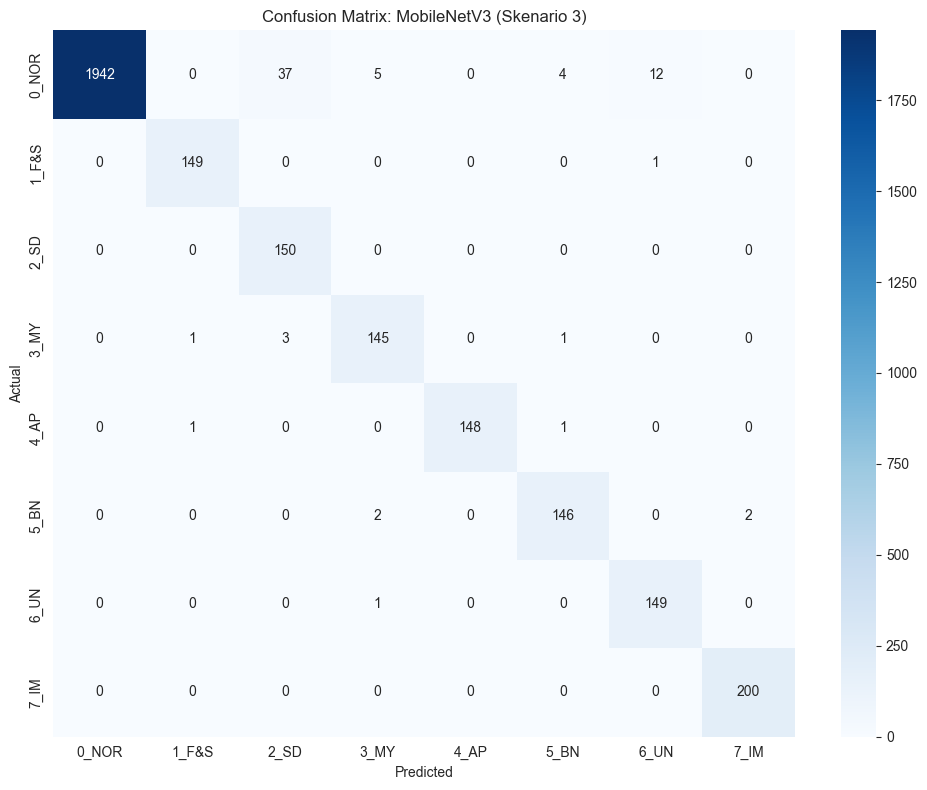


=== Detail Report per Kelas: MobileNetV3 (Skenario 3) ===


,precision,recall,f1-score,support
0_NOR,1.000000,0.971000,0.985287,2000.000000
1_F&S,0.986755,0.993333,0.990033,150.000000
2_SD,0.789474,1.000000,0.882353,150.000000
3_MY,0.947712,0.966667,0.957096,150.000000
4_AP,1.000000,0.986667,0.993289,150.000000
5_BN,0.960526,0.973333,0.966887,150.000000
6_UN,0.919753,0.993333,0.955128,150.000000
7_IM,0.990099,1.000000,0.995025,200.000000
accuracy,0.977097,0.977097,0.977097,0.977097
macro avg,0.949290,0.985542,0.965637,3100.000000


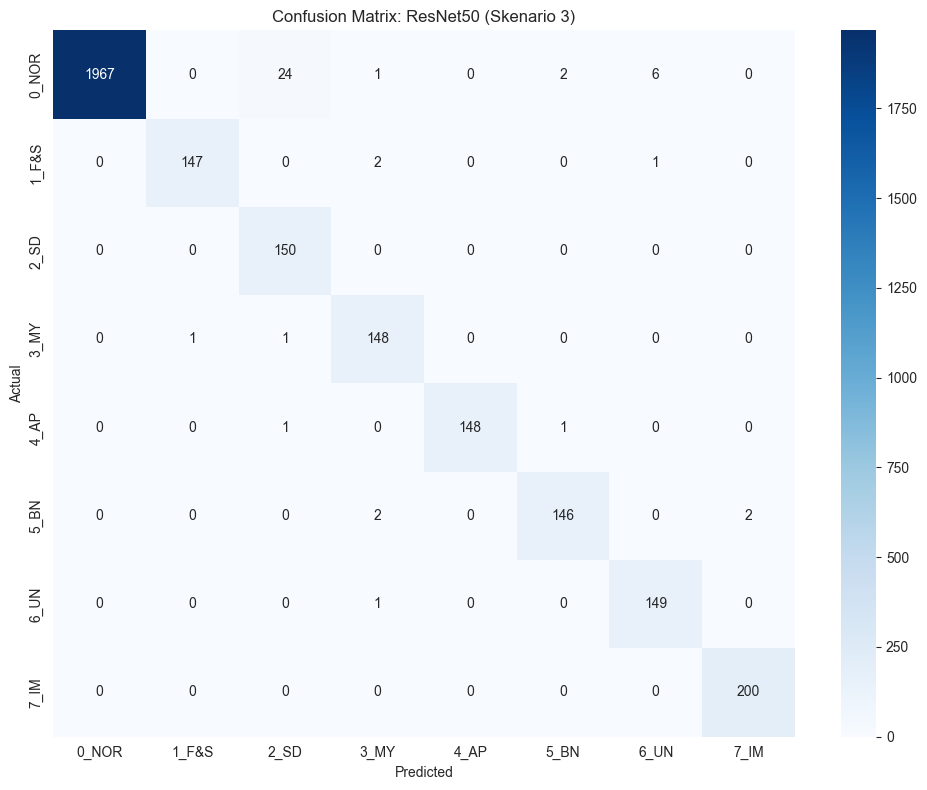


=== Detail Report per Kelas: ResNet50 (Skenario 3) ===


,precision,recall,f1-score,support
0_NOR,1.000000,0.983500,0.991681,2000.000000
1_F&S,0.993243,0.980000,0.986577,150.000000
2_SD,0.852273,1.000000,0.920245,150.000000
3_MY,0.961039,0.986667,0.973684,150.000000
4_AP,1.000000,0.986667,0.993289,150.000000
5_BN,0.979866,0.973333,0.976589,150.000000
6_UN,0.955128,0.993333,0.973856,150.000000
7_IM,0.990099,1.000000,0.995025,200.000000
accuracy,0.985484,0.985484,0.985484,0.985484
macro avg,0.966456,0.987938,0.976368,3100.000000


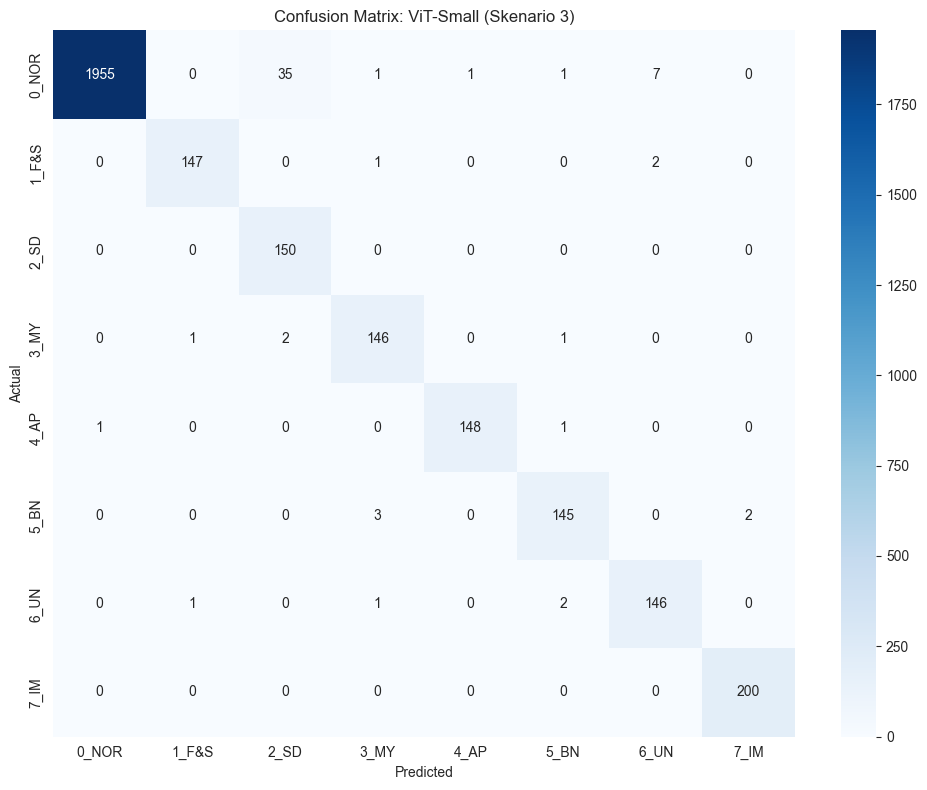


=== Detail Report per Kelas: ViT-Small (Skenario 3) ===


,precision,recall,f1-score,support
0_NOR,0.999489,0.977500,0.988372,2000.000000
1_F&S,0.986577,0.980000,0.983278,150.000000
2_SD,0.802139,1.000000,0.890208,150.000000
3_MY,0.960526,0.973333,0.966887,150.000000
4_AP,0.993289,0.986667,0.989967,150.000000
5_BN,0.966667,0.966667,0.966667,150.000000
6_UN,0.941935,0.973333,0.957377,150.000000
7_IM,0.990099,1.000000,0.995025,200.000000
accuracy,0.979677,0.979677,0.979677,0.979677
macro avg,0.955090,0.982187,0.967222,3100.000000


In [19]:
def plot_detail_model(scenario, model_name):
    # Cek skenario
    if scenario not in results_matrix:
        print(f"⚠️ {scenario} tidak ditemukan di results_matrix")
        return

    # Cek model
    if model_name not in results_matrix[scenario]:
        print(f"⚠️ {model_name} tidak ditemukan pada {scenario}")
        return

    data = results_matrix[scenario][model_name]

    if data is None:
        print(f"⚠️ {model_name} tidak punya data")
        return

    # Ambil confusion matrix dan classification report
    if "cm" in data:
        cm = data["cm"]
    elif "Confusion Matrix" in data:
        cm = data["Confusion Matrix"]
    else:
        print(f"⚠️ Confusion Matrix untuk {model_name} tidak ditemukan")
        return

    if "report" in data:
        report = data["report"]
    elif "Full Report" in data:
        report = data["Full Report"]
    else:
        print(f"⚠️ Classification report untuk {model_name} tidak ditemukan")
        return

    # Plot Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=train_dataset.classes,
        yticklabels=train_dataset.classes,
    )
    plt.title(f"Confusion Matrix: {model_name} ({scenario})")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    # Tampilkan Classification Report
    print(f"\n=== Detail Report per Kelas: {model_name} ({scenario}) ===")
    report_df = pd.DataFrame(report).transpose()
    display(report_df)


plot_detail_model("Skenario 3", "MobileNetV3")
plot_detail_model("Skenario 3", "ResNet50")
plot_detail_model("Skenario 3", "ViT-Small")

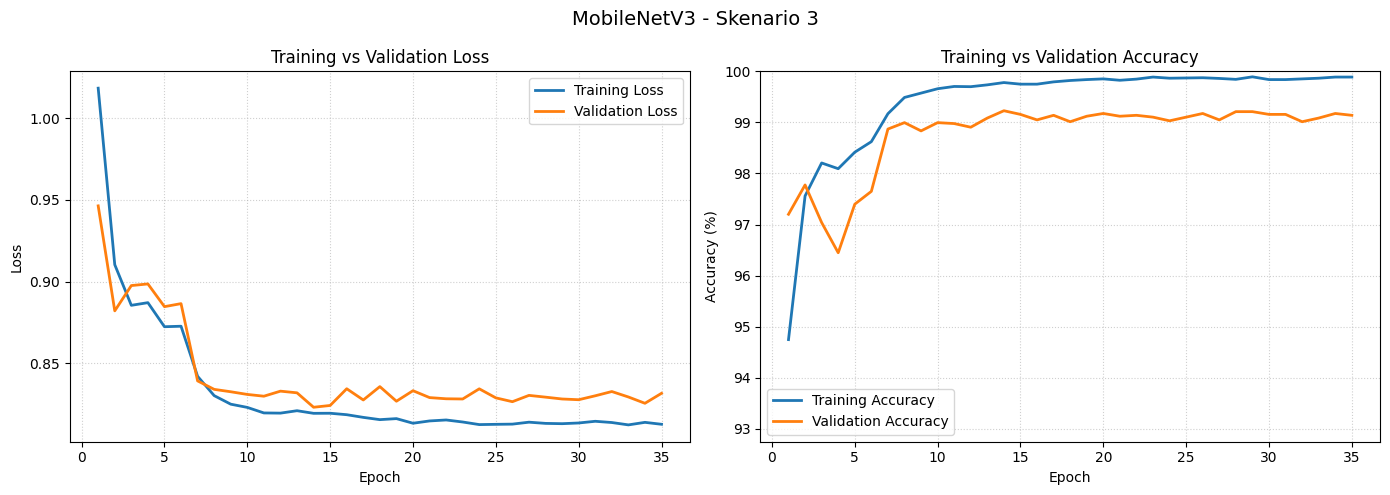

✅ Grafik MobileNetV3 berhasil ditampilkan


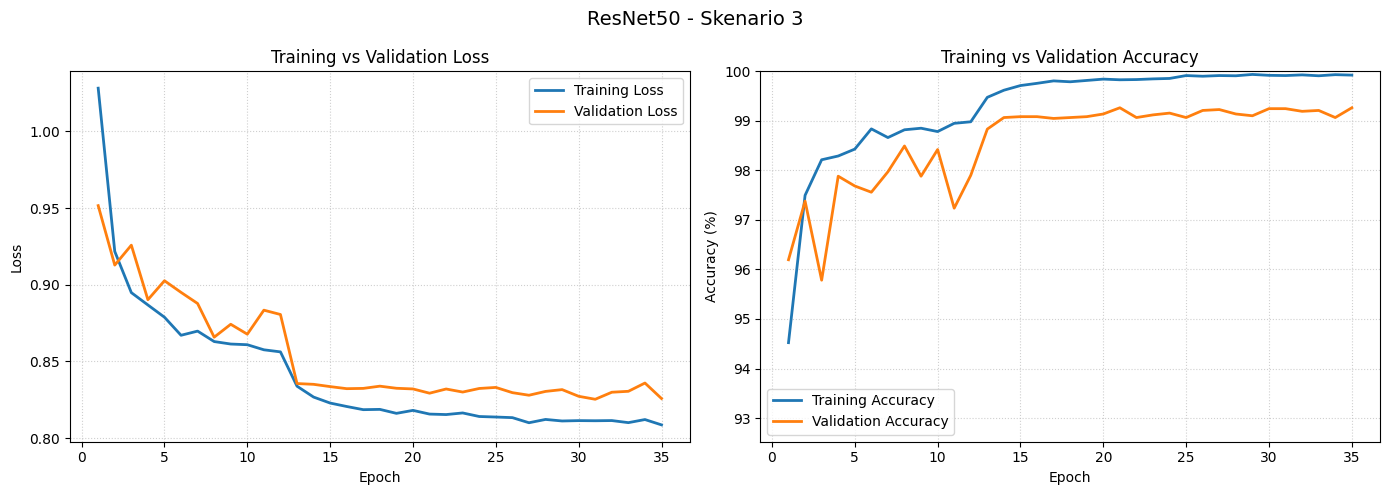

✅ Grafik ResNet50 berhasil ditampilkan


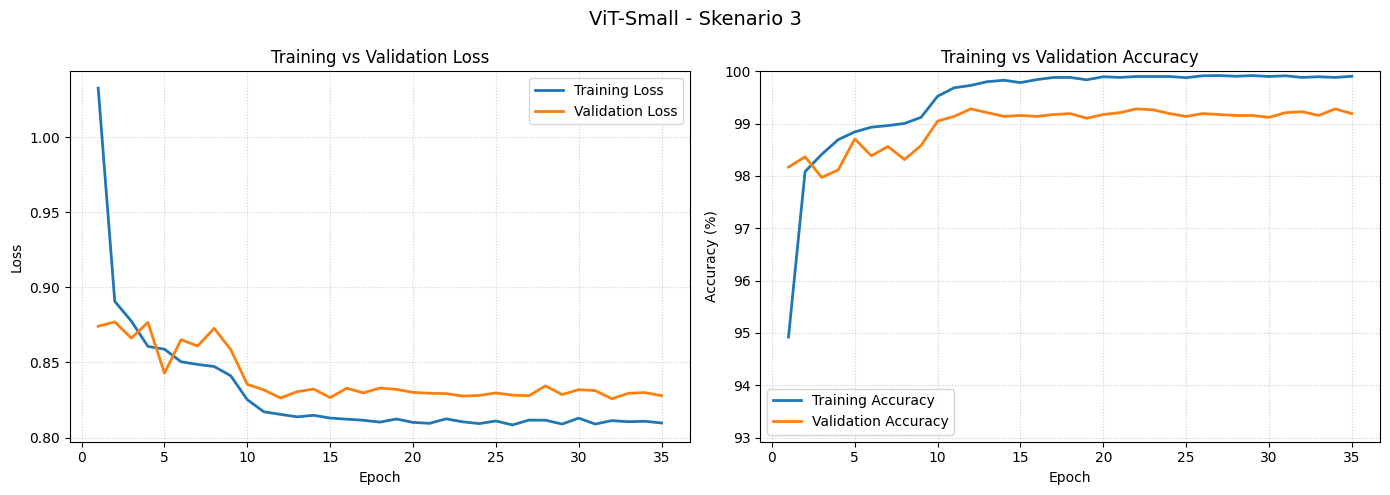

✅ Grafik ViT-Small berhasil ditampilkan


In [20]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_loss_dan_akurasi(scenario_name):

    # =========================
    # Validasi skenario
    # =========================
    if scenario_name not in results_matrix:
        print(f"⚠️ {scenario_name} tidak ditemukan di results_matrix")
        return

    scenario_data = results_matrix[scenario_name]

    if not scenario_data:
        print(f"⚠️ Data untuk {scenario_name} kosong")
        return

    # =========================
    # Loop tiap model
    # =========================
    for model_name, data in scenario_data.items():

        if data is None:
            print(f"⚠️ {model_name} tidak punya data")
            continue

        # =========================
        # Ambil history
        # =========================
        if "history" in data:
            history = data["history"]
        elif "History" in data:
            history = data["History"]
        else:
            print(f"⚠️ History training {model_name} tidak ditemukan")
            continue

        # =========================
        # Validasi isi history
        # =========================
        required_keys = [
            "train_loss",
            "val_loss",
            "train_acc",
            "val_acc",
        ]

        missing_keys = [k for k in required_keys if k not in history]

        if missing_keys:
            print(f"⚠️ {model_name} missing key: {missing_keys}")
            continue

        epochs = range(1, len(history["train_acc"]) + 1)

        # =========================
        # Ambil data
        # =========================
        train_loss = history["train_loss"]
        val_loss = history["val_loss"]

        train_acc = history["train_acc"]
        val_acc = history["val_acc"]

        # =========================
        # Konversi accuracy jika masih 0-1
        # =========================
        if max(train_acc) <= 1.0:
            train_acc = [x * 100 for x in train_acc]

        if max(val_acc) <= 1.0:
            val_acc = [x * 100 for x in val_acc]

        # =========================
        # Plot
        # =========================
        plt.style.use("default")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # =====================================
        # LOSS
        # =====================================
        axes[0].plot(
            epochs,
            train_loss,
            linewidth=2,
            label="Training Loss",
        )

        axes[0].plot(
            epochs,
            val_loss,
            linewidth=2,
            label="Validation Loss",
        )

        axes[0].set_title("Training vs Validation Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")

        axes[0].legend()

        axes[0].grid(
            True,
            linestyle=":",
            alpha=0.6
        )

        # =====================================
        # ACCURACY
        # =====================================
        axes[1].plot(
            epochs,
            train_acc,
            linewidth=2,
            label="Training Accuracy",
        )

        axes[1].plot(
            epochs,
            val_acc,
            linewidth=2,
            label="Validation Accuracy",
        )

        axes[1].set_title("Training vs Validation Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy (%)")

        # Auto zoom
        min_acc = min(min(train_acc), min(val_acc))
        max_acc = max(max(train_acc), max(val_acc))

        axes[1].set_ylim(
            max(0, min_acc - 2),
            min(100, max_acc + 2)
        )

        axes[1].legend()

        axes[1].grid(
            True,
            linestyle=":",
            alpha=0.6
        )

        # =====================================
        # Judul utama
        # =====================================
        fig.suptitle(
            f"{model_name} - {scenario_name}",
            fontsize=14
        )

        plt.tight_layout()

        # =====================================
        # Optional save
        # =====================================
        # file_name = f"Graph_{model_name}_{scenario_name}.png"
        # plt.savefig(file_name, dpi=300, bbox_inches="tight")

        plt.show()

        print(f"✅ Grafik {model_name} berhasil ditampilkan")


# =========================
# Jalankan
# =========================
plot_loss_dan_akurasi("Skenario 3")

# 3. Struktur Tabel untuk Paper (Pandas)
Setelah semua eksperimen selesai, Anda bisa mengubah results_matrix menjadi DataFrame agar bisa langsung di-copy ke tabel Microsoft Word untuk artikel SINTA 3 Anda.

In [21]:
import pandas as pd


def summary_to_table():
    summary_list = []
    for scenario, models in results_matrix.items():
        for model_name, data in models.items():
            if data is not None:
                summary_list.append(
                    {
                        "Scenario": scenario,
                        "Model": model_name,
                        "Accuracy": f"{data['Accuracy']*100:.2f}%",
                        "Macro F1": f"{data['Macro F1']:.4f}",
                        "Weighted F1": f"{data['Weighted F1']:.4f}",
                        "Time (Min)": f"{data['Time']:.2f}",
                    }
                )
    return pd.DataFrame(summary_list)


# Panggil ini setelah semua training selesai
df_hasil = summary_to_table()
print(df_hasil)

     Scenario        Model Accuracy Macro F1 Weighted F1 Time (Min)
0  Skenario 3  MobileNetV3   97.71%   0.9656      0.9778      45.73
1  Skenario 3     ResNet50   98.55%   0.9764      0.9858      69.61
2  Skenario 3    ViT-Small   97.97%   0.9672      0.9803      61.16
